# Notebook 04 — Funções de Ativação

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- implementar ReLU, Sigmoid, Tanh e Softmax;
- entender o intervalo e o uso típico de cada função;
- diferenciar pré-ativação `Z` e ativação `A`;
- aplicar ReLU à saída de uma camada.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


## 1. ReLU

A função **Rectified Linear Unit** é definida por `max(0, x)`: valores negativos se tornam zero, e valores positivos são preservados. Ela é muito usada em camadas ocultas por ser simples e eficiente.


In [ ]:
def relu(x):
    return np.maximum(0, x)

In [ ]:
valores = np.array([-5, -2, 0, 2, 5])

resultado = relu(valores)

print(resultado)

[0 0 0 2 5]


## 2. Sigmoid

A Sigmoid transforma qualquer número real em um valor entre 0 e 1. É frequentemente usada na saída de classificadores binários. Uma saída próxima de 1 indica maior confiança na classe positiva, mas não deve ser interpretada automaticamente como probabilidade sem considerar o treinamento e a calibração do modelo.

\[
\sigma(x)=
rac{1}{1+e^{-x}}
\]


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
valores = np.array([-5, -2, 0, 2, 5])

print(sigmoid(valores))

[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


## 3. Tanh

A tangente hiperbólica produz valores entre -1 e 1. Diferentemente da Sigmoid, é centrada em zero, mas também pode apresentar gradientes muito pequenos para entradas extremas.


In [ ]:
def tanh(x):
    return np.tanh(x)

In [ ]:
print(tanh(valores))

[-0.9999092  -0.96402758  0.          0.96402758  0.9999092 ]


## 4. Softmax

Softmax transforma um vetor de scores em uma distribuição cuja soma é 1. Ela é usada na camada de saída de classificações com múltiplas classes mutuamente exclusivas.

A subtração de `np.max(x)` melhora a estabilidade numérica sem alterar as probabilidades finais.


In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

In [ ]:
valores = np.array([2.5, 1.2, 0.3])

probabilidades = softmax(valores)

print(probabilidades)
print("Soma:", np.sum(probabilidades))

[0.72289072 0.1970107  0.08009858]
Soma: 1.0


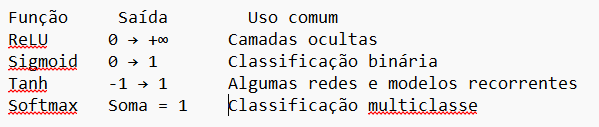

## 5. Inserindo uma ativação na camada

Antes, calculamos apenas a transformação linear:

\[
Z = XW + b
\]

Agora aplicamos a ativação:

\[
A = ReLU(Z)
\]


ENTRADA

   │

   ▼

X @ W

   │

   ▼
   
+BIAS

   │

   ▼

Z

   │

   ▼

RELU

   │

   ▼

A

- `Z`: resultado antes da função de ativação, também chamado de **pré-ativação**;
- `A`: resultado após a função de ativação, também chamado de **ativação**.


In [ ]:
import numpy as np

entradas = np.array([
    [2, 3],
    [4, 5],
    [6, 7],
    [8, 9]
])

pesos = np.array([
    [0.5, 0.8, 0.2],
    [0.3, 0.7, 0.9]
])

bias = np.array([1, 2, 3])

In [ ]:
Z = entradas @ pesos + bias

print("Z:")
print(Z)

Z:
[[ 2.9  5.7  6.1]
 [ 4.5  8.7  8.3]
 [ 6.1 11.7 10.5]
 [ 7.7 14.7 12.7]]


In [ ]:
A = relu(Z)

print("A:")
print(A)

A:
[[ 2.9  5.7  6.1]
 [ 4.5  8.7  8.3]
 [ 6.1 11.7 10.5]
 [ 7.7 14.7 12.7]]


Como todos os valores de `Z` são positivos neste exemplo, a ReLU não altera a matriz e obtemos `A = Z`. A próxima célula testa valores negativos para tornar o efeito visível.


In [ ]:
Z_teste = np.array([
    [-2, 3, -5],
    [4, -1, 2]
])

print("Antes da ReLU:")
print(Z_teste)

print("Depois da ReLU:")
print(relu(Z_teste))

Antes da ReLU:
[[-2  3 -5]
 [ 4 -1  2]]
Depois da ReLU:
[[0 3 0]
 [4 0 2]]


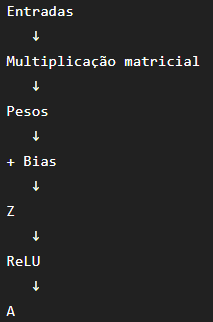

## 6. Transformação linear e não linearidade

Uma transformação linear simples pode ser escrita como `y = mx + b`. Uma camada Dense generaliza essa ideia para vetores e matrizes. Sem uma função de ativação não linear, empilhar várias camadas lineares continuaria equivalente a uma única transformação linear.


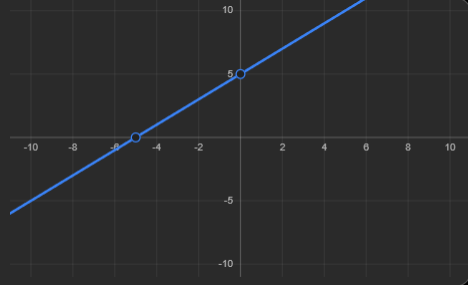

A visualização representa uma transformação linear. Uma camada neural é mais geral porque combina várias características e neurônios por meio de matrizes, adiciona bias e depois aplica uma função de ativação.


## 7. Revisão do fluxo

```text
Entradas X
   ↓
Z = XW + b
   ↓
A = ativação(Z)
```

A função de ativação permite que a rede represente relações não lineares.


Até aqui, definimos manualmente os pesos e biases para compreender o cálculo interno de uma camada.


No próximo notebook, deixaremos de escolher esses parâmetros manualmente e implementaremos o processo que permite ao modelo aprendê-los a partir dos dados.


## 🧠 Conclusão

Funções de ativação determinam como uma camada transforma sua pré-ativação. A escolha depende do tipo de camada e do problema:

- ReLU: camadas ocultas;
- Sigmoid: saída binária;
- Softmax: saída multiclasse;
- Tanh: útil em alguns modelos com valores centrados em zero.

### Exercícios

1. Teste as quatro funções com valores entre -10 e 10.
2. Plote cada função com Matplotlib.
3. Explique por que a soma da saída de Softmax é igual a 1.

### Próximo notebook

No Notebook 05, implementaremos loss, gradientes, backpropagation e Gradient Descent apenas com NumPy.
